# Determination Anti-Dictionnaire

Dans ce notebook nous effectuons une analyse basique statistique pour détèrminer le bon seuil td-idf pour considérer qu'un token est un stop word.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS = Path("../exercices-td/outputs-td2")

In [8]:
tfidf = pd.read_csv(OUTPUTS / "tf_idf.tsv", sep = "\t")
idf = pd.read_csv(OUTPUTS / "idf.tsv", sep = "\t")
tf = pd.read_csv(OUTPUTS / "tf.tsv", sep = "\t")

<Axes: xlabel='tf_idf', ylabel='Count'>

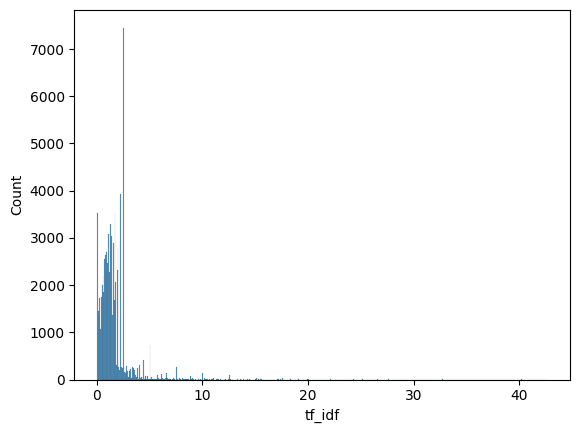

In [9]:
sns.histplot(tfidf, x="tf_idf")

<Axes: xlabel='idf', ylabel='Count'>

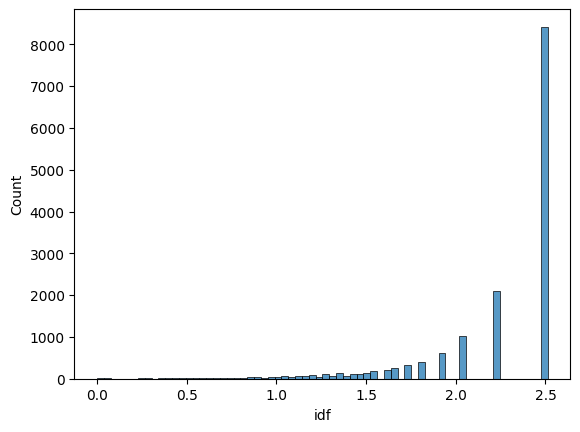

In [10]:
sns.histplot(idf, x="idf")

In [11]:
grouped_tfidf = tfidf.groupby("token").mean().reset_index().rename(columns={"tf_idf" : "mean_tf_idf"})
grouped_tfidf["var_tf_idf"] = tfidf.groupby("token").var(ddof=0)["tf_idf"].to_list()
grouped_tfidf.sort_values("mean_tf_idf").iloc[50:100]

,token,document_id,mean_tf_idf,var_tf_idf
6863,il,71608.142857,0.618245,0.318228
6691,hui,71687.265152,0.633584,0.111300
1554,aujourd,71687.265152,0.633584,0.111300
12740,si,71857.706897,0.642190,0.139665
14977,étant,71687.958763,0.645846,0.077173
4325,donc,71951.524194,0.650007,0.140286
11582,recherche,71604.294118,0.667001,0.296838
9638,ont,71732.762712,0.677347,0.211358
7724,jusqu,70979.215054,0.679454,0.112670
2557,cet,71945.126214,0.680129,0.135421


# Choix cutoff

Au vu des mots dans la liste ci dessus. Le cutoff de 0.7 pour la tf-idf semble pertinent.

<Axes: xlabel='var_tf_idf', ylabel='Count'>

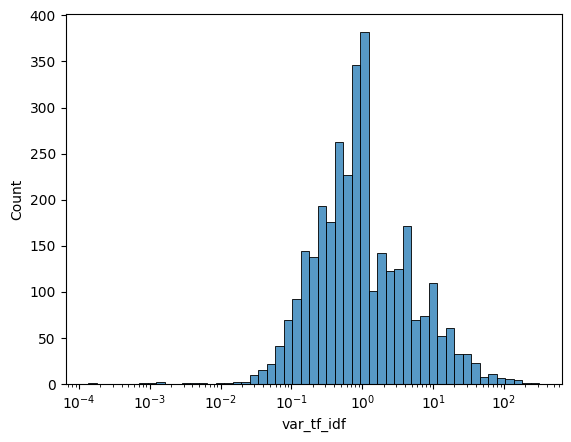

In [12]:
sns.histplot(grouped_tfidf, x = "var_tf_idf", log_scale=True)

In [13]:
tfidf.groupby("token")["tf_idf"].count()

token
-        41
--       25
-80       1
-la       1
0         2
         ..
êtres     1
île       3
îles      2
îlots     1
œil       1
Name: tf_idf, Length: 15081, dtype: int64